In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functions import *

In [2]:
file_name = 'data_train_augm_Pb.xlsx'
df = read_excel(file_name, sheet_name = 'Relavage Pb')

In [3]:
fft_features = []
labels_cu = []
labels_pb = []
labels_fe = []
labels_zn = []
for line in df.values:
    image = cv2.imread("../train_resizedimages/"+line[0])
    fft_pca = image_to_fft_pca(image)
    fft_features.append(fft_pca)
    labels_cu.append(line[1])
    labels_fe.append(line[2])
    labels_pb.append(line[3])
    labels_zn.append(line[4])
fft_features = np.array(fft_features)
labels_cu = np.array(labels_cu)
labels_fe = np.array(labels_fe)
labels_pb = np.array(labels_pb)
labels_zn = np.array(labels_zn)
labels = np.array([labels_cu, labels_fe, labels_pb, labels_zn]).T

In [4]:
fft_features.shape

(1558, 400)

In [5]:
labels.shape

(1558, 4)

In [6]:
X = pd.DataFrame(fft_features, columns = ['fft_pca_{}'.format(i) for i in range(fft_features.shape[1])])
y = pd.DataFrame(labels, columns = ['Cu', 'Fe', 'Pb', 'Zn'])

In [81]:
df = pd.concat([X, y], axis = 1)

In [82]:
df

,fft_pca_0,fft_pca_1,fft_pca_2,fft_pca_3,fft_pca_4,fft_pca_5,fft_pca_6,fft_pca_7,fft_pca_8,fft_pca_9,...,fft_pca_394,fft_pca_395,fft_pca_396,fft_pca_397,fft_pca_398,fft_pca_399,Cu,Fe,Pb,Zn
0,-19.423788,-19.540990,-20.454399,-19.984389,-19.417173,-20.007269,-19.453091,-20.489231,-19.142579,-19.077429,...,-19.453091,-20.007269,-19.417173,-19.984389,-20.454399,-19.540990,1.245513,6.959282,13.938595,3.244900
1,-18.539574,-18.394321,-18.547846,-16.722499,-17.718530,-17.976798,-19.173177,-18.212724,-18.227286,-17.886158,...,-19.173177,-17.976798,-17.718530,-16.722499,-18.547846,-18.394321,1.967959,7.476666,13.957256,3.316974
2,-18.079604,-17.941186,-17.342125,-16.999932,-17.357601,-18.236503,-17.077571,-16.729141,-17.268557,-16.472840,...,-17.077571,-18.236503,-17.357601,-16.999932,-17.342125,-17.941186,1.738068,8.358878,13.832301,2.216290
3,-16.301260,-18.154291,-16.972588,-17.172573,-18.556910,-18.546567,-18.361408,-18.552962,-17.466755,-17.064904,...,-18.361408,-18.546567,-18.556910,-17.172573,-16.972588,-18.154291,1.695532,8.051285,13.553668,1.922395
4,-19.158780,-19.356368,-19.414949,-17.597629,-19.220706,-18.622567,-18.719148,-19.365365,-18.551759,-18.128892,...,-18.719148,-18.622567,-19.220706,-17.597629,-19.414949,-19.356368,0.609515,8.413778,13.492315,2.881374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,-18.902400,-17.698634,-19.182420,-19.525752,-19.100536,-19.236931,-18.514596,-18.803507,-18.102646,-18.669893,...,-18.514596,-19.236931,-19.100536,-19.525752,-19.182420,-17.698634,0.594924,10.860318,50.687493,3.865887
1554,-17.847626,-18.675223,-19.271607,-18.150635,-18.429817,-18.386851,-18.805090,-18.626089,-18.949218,-19.479850,...,-18.805090,-18.386851,-18.429817,-18.150635,-19.271607,-18.675223,1.625748,9.903235,50.588142,4.437520
1555,-17.931530,-17.667358,-17.610701,-18.721773,-17.835597,-18.138604,-18.960293,-19.131746,-18.456959,-19.040806,...,-18.960293,-18.138604,-17.835597,-18.721773,-17.610701,-17.667358,0.798550,10.961176,50.785080,4.004402
1556,-18.035867,-19.100674,-18.950447,-18.559832,-18.142072,-17.349995,-17.369275,-19.026689,-19.030817,-17.819371,...,-17.369275,-17.349995,-18.142072,-18.559832,-18.950447,-19.100674,0.903597,10.362348,50.590920,5.283421


In [9]:
df.describe()

,fft_pca_0,fft_pca_1,fft_pca_2,fft_pca_3,fft_pca_4,fft_pca_5,fft_pca_6,fft_pca_7,fft_pca_8,fft_pca_9,...,fft_pca_394,fft_pca_395,fft_pca_396,fft_pca_397,fft_pca_398,fft_pca_399,Cu,Fe,Pb,Zn
count,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,...,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000,1558.000000
mean,-19.392914,-19.368901,-19.333453,-19.274326,-19.261060,-19.189546,-19.167089,-19.095102,-19.057574,-19.012911,...,-19.167089,-19.189546,-19.261060,-19.274326,-19.333453,-19.368901,2.289277,11.602477,40.622340,4.820575
std,2.691376,2.611463,2.588038,2.656868,2.607536,2.655518,2.609977,2.625874,2.639354,2.609065,...,2.609977,2.655518,2.607536,2.656868,2.588038,2.611463,1.034613,4.436700,15.750841,1.586584
min,-25.482605,-24.485813,-24.885540,-25.042368,-24.550235,-24.840350,-25.082615,-24.442842,-24.848278,-25.153729,...,-25.082615,-24.840350,-24.550235,-25.042368,-24.885540,-24.485813,0.131486,2.537478,12.244314,0.899954
25%,-20.770818,-20.663646,-20.588380,-20.594151,-20.632426,-20.530250,-20.549467,-20.443822,-20.395348,-20.434844,...,-20.549467,-20.530250,-20.632426,-20.594151,-20.588380,-20.663646,1.503903,7.904694,25.326107,3.497475
50%,-19.405767,-19.399500,-19.313079,-19.298822,-19.241782,-19.216288,-19.169732,-19.133063,-19.081885,-18.962019,...,-19.169732,-19.216288,-19.241782,-19.298822,-19.313079,-19.399500,2.178954,11.139290,45.577782,5.049387
75%,-18.242690,-18.266015,-18.240426,-18.096518,-18.106764,-18.007927,-18.031900,-17.841464,-17.852986,-17.732761,...,-18.031900,-18.007927,-18.106764,-18.096518,-18.240426,-18.266015,3.001987,15.004434,52.984005,6.016921
max,25.248336,23.804305,22.706597,24.279159,23.312829,24.341545,22.038865,24.042238,23.670831,23.583008,...,22.038865,24.341545,23.312829,24.279159,22.706597,23.804305,4.888421,19.753037,63.608303,8.456079


In [8]:
df.corr()

,fft_pca_0,fft_pca_1,fft_pca_2,fft_pca_3,fft_pca_4,fft_pca_5,fft_pca_6,fft_pca_7,fft_pca_8,fft_pca_9,...,fft_pca_394,fft_pca_395,fft_pca_396,fft_pca_397,fft_pca_398,fft_pca_399,Cu,Fe,Pb,Zn
fft_pca_0,1.000000,0.913661,0.912660,0.912563,0.904846,0.908610,0.909284,0.902708,0.907756,0.901895,...,0.909284,0.908610,0.904846,0.912563,0.912660,0.913661,-0.093753,-0.060465,0.049022,-0.059384
fft_pca_1,0.913661,1.000000,0.937027,0.939955,0.935414,0.933530,0.930565,0.930789,0.930598,0.926173,...,0.930565,0.933530,0.935414,0.939955,0.937027,1.000000,-0.097830,-0.072571,0.068725,-0.059955
fft_pca_2,0.912660,0.937027,1.000000,0.940439,0.933834,0.934801,0.931128,0.931574,0.930052,0.926310,...,0.931128,0.934801,0.933834,0.940439,1.000000,0.937027,-0.112154,-0.078768,0.064486,-0.067628
fft_pca_3,0.912563,0.939955,0.940439,1.000000,0.940932,0.939643,0.937656,0.936535,0.934786,0.932361,...,0.937656,0.939643,0.940932,1.000000,0.940439,0.939955,-0.102361,-0.083230,0.059391,-0.068848
fft_pca_4,0.904846,0.935414,0.933834,0.940932,1.000000,0.942436,0.938711,0.935816,0.934276,0.933466,...,0.938711,0.942436,1.000000,0.940932,0.933834,0.935414,-0.115838,-0.085981,0.068380,-0.067423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fft_pca_399,0.913661,1.000000,0.937027,0.939955,0.935414,0.933530,0.930565,0.930789,0.930598,0.926173,...,0.930565,0.933530,0.935414,0.939955,0.937027,1.000000,-0.097830,-0.072571,0.068725,-0.059955
Cu,-0.093753,-0.097830,-0.112154,-0.102361,-0.115838,-0.117951,-0.124088,-0.132631,-0.134209,-0.130513,...,-0.124088,-0.117951,-0.115838,-0.102361,-0.112154,-0.097830,1.000000,0.472882,-0.079607,0.465310
Fe,-0.060465,-0.072571,-0.078768,-0.083230,-0.085981,-0.094737,-0.101371,-0.100662,-0.111941,-0.100876,...,-0.101371,-0.094737,-0.085981,-0.083230,-0.078768,-0.072571,0.472882,1.000000,-0.573209,0.742344
Pb,0.049022,0.068725,0.064486,0.059391,0.068380,0.063147,0.066357,0.055525,0.067565,0.059269,...,0.066357,0.063147,0.068380,0.059391,0.064486,0.068725,-0.079607,-0.573209,1.000000,-0.131645


<AxesSubplot:>

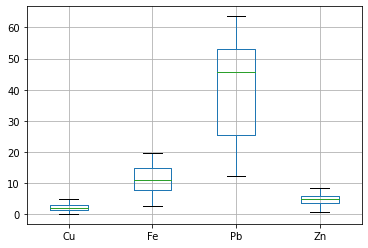

In [17]:
df[["Cu", "Fe", "Pb", "Zn"]].boxplot()

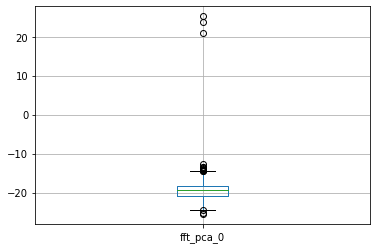

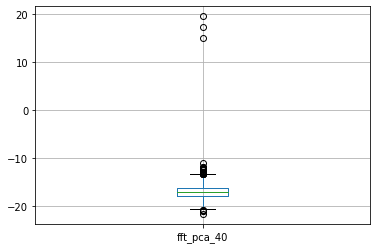

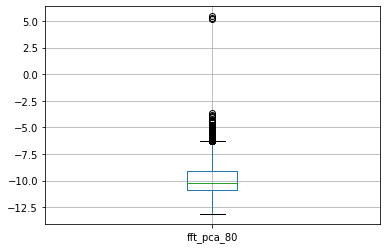

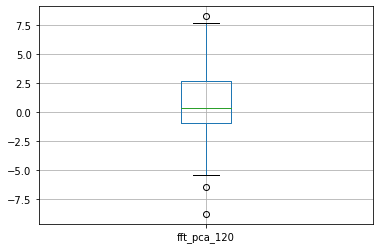

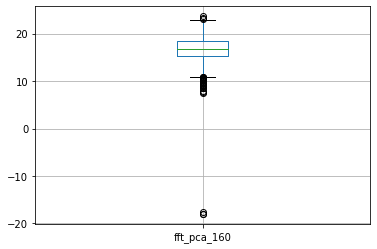

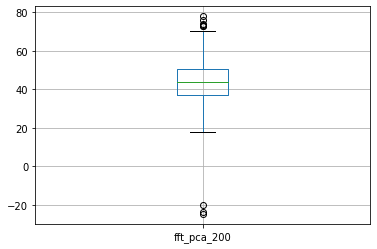

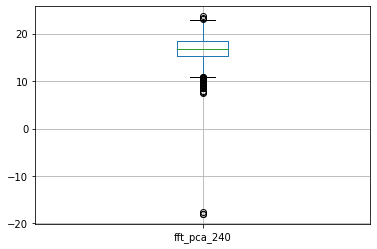

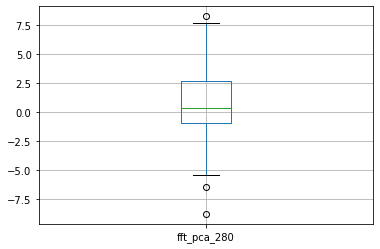

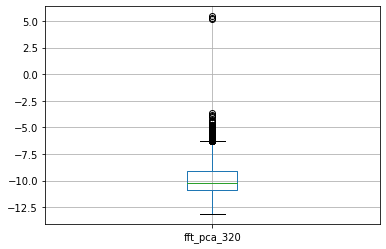

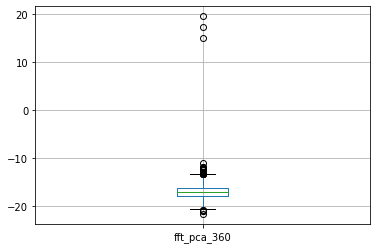

In [42]:
for i in range(400):
    if i % 40 == 0:
        df[["fft_pca_"+str(i)]].boxplot()
        plt.show()

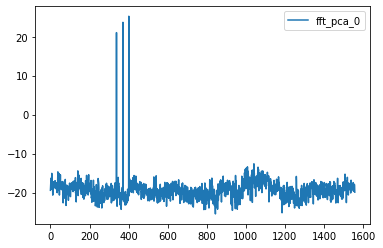

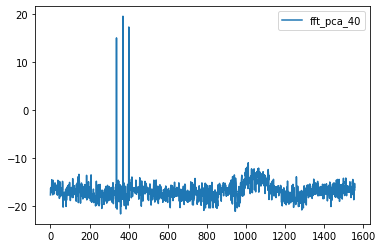

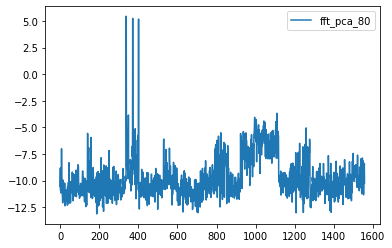

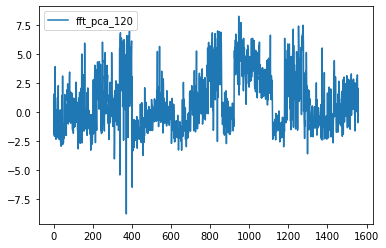

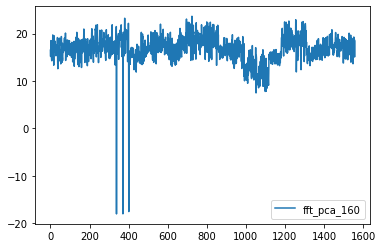

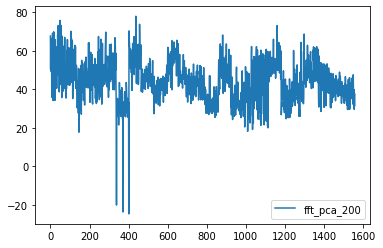

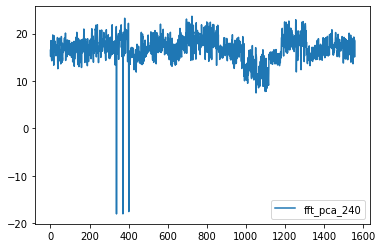

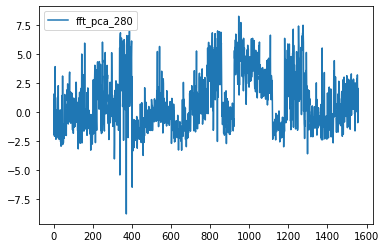

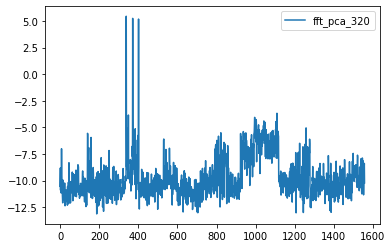

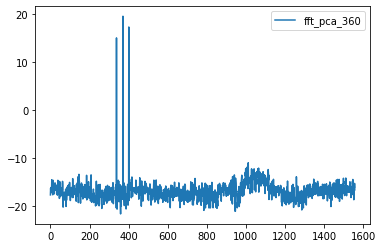

In [46]:
for i in range(400):
    if i % 40 == 0:
        df[["fft_pca_"+str(i)]].plot()
        plt.show()

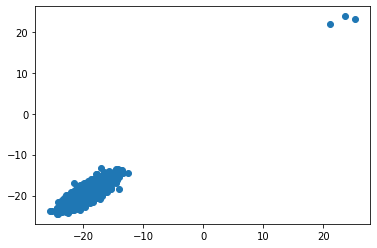

In [83]:
plt.scatter(df["fft_pca_0"], df["fft_pca_399"])
plt.show()